In [95]:
###############################
####### Log parser code #######
###############################

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [96]:
# Load the CSV file
df = pd.read_csv('logs/drone_log.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

# Display first few rows
df.head()

# Display data types and non-null counts
df.info()

# Basic statistics
df.describe()

Dataset Shape: (158, 18)

Column Names:
['timestamp', 'pitch', 'roll', 'yaw', 'gyro_temp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'height_tof_mm', 'height_baro_m', 'battery_main_voltage', 'battery_edf_voltage', 'temperature', 'humidity', 'pressure']
<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             158 non-null    int64  
 1   pitch                 158 non-null    float64
 2   roll                  158 non-null    float64
 3   yaw                   158 non-null    float64
 4   gyro_temp             158 non-null    int64  
 5   accel_x               158 non-null    float64
 6   accel_y               158 non-null    float64
 7   accel_z               158 non-null    float64
 8   gyro_x                158 non-null    float64
 9   gyro_y                158 non-null    float64
 10  gyro_z         

,timestamp,pitch,roll,yaw,gyro_temp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,height_tof_mm,height_baro_m,battery_main_voltage,battery_edf_voltage,temperature,humidity,pressure
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.0,158.0,158.000000,158.000000,158.0,158.0,158.000000
mean,56751.272152,0.627141,-1.292006,-0.021669,2185.715190,-1.008176,-0.022892,0.011336,-4.333897,-1.307808,0.896222,0.0,97.0,1102.898734,2.898734,2611.0,40.0,101526.316456
std,956.165355,0.020983,0.017496,0.000275,0.452759,0.003118,0.002453,0.004021,0.054980,0.066511,0.060813,0.0,0.0,3.750482,0.481371,0.0,0.0,0.917547
min,55145.000000,0.579829,-1.335512,-0.022405,2185.000000,-1.015352,-0.029541,-0.001465,-4.480916,-1.465649,0.717557,0.0,97.0,1094.000000,0.000000,2611.0,40.0,101525.000000
25%,55920.000000,0.611680,-1.306359,-0.021832,2185.000000,-1.010652,-0.024658,0.009277,-4.366412,-1.358779,0.856870,0.0,97.0,1100.000000,3.000000,2611.0,40.0,101526.000000
50%,56745.500000,0.626419,-1.286678,-0.021660,2186.000000,-1.008271,-0.022949,0.011963,-4.332061,-1.305344,0.893130,0.0,97.0,1103.500000,3.000000,2611.0,40.0,101526.000000
75%,57550.250000,0.642017,-1.277970,-0.021489,2186.000000,-1.005830,-0.020996,0.013672,-4.297710,-1.251908,0.938931,0.0,97.0,1105.000000,3.000000,2611.0,40.0,101527.000000
max,58455.000000,0.683245,-1.257350,-0.021069,2186.000000,-0.999482,-0.016602,0.020996,-4.213740,-1.160305,1.045802,0.0,97.0,1110.000000,3.000000,2611.0,40.0,101528.000000


In [97]:
### Data Preprocessing ###

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Convert timestamp to seconds
df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000  

# Create time in minutes for easier plotting
df['time_min'] = df['time_sec'] / 360

# Convert pressure from Pa to hPa for better readability
df['pressure_hpa'] = df['pressure'] / 100

# Convert heights to meters
df['height_tof_m'] = df['height_tof_mm'] / 1000
df['height_baro_m'] = df['height_baro_m']  # Already in meters

#Convert temperature
df['temperature_c'] = df['temperature'] / 100 

# Convert battery voltages to actual volts (assuming scaling of 1000 based on typical values)
df['battery_main_voltage_v'] = df['battery_main_voltage'] / 100
df['battery_edf_voltage_v'] = df['battery_edf_voltage'] / 100

# Convert gyro temperature from raw to Celsius 
# temperature_C = (raw_value / 340.0) + 36.53 for some IMUs

df['gyro_temp_c'] = df['gyro_temp'] / 100 

# Display the new columns
df[['timestamp', 'time_sec', 'time_min', 'gyro_temp', 'gyro_temp_c', 
    'battery_main_voltage', 'battery_main_voltage_v', 'temperature_c', 'pressure_hpa']].head()


Missing values in each column:
timestamp               0
pitch                   0
roll                    0
yaw                     0
gyro_temp               0
accel_x                 0
accel_y                 0
accel_z                 0
gyro_x                  0
gyro_y                  0
gyro_z                  0
height_tof_mm           0
height_baro_m           0
battery_main_voltage    0
battery_edf_voltage     0
temperature             0
humidity                0
pressure                0
dtype: int64


,timestamp,time_sec,time_min,gyro_temp,gyro_temp_c,battery_main_voltage,battery_main_voltage_v,temperature_c,pressure_hpa
0,55145,0.000,0.000000,2186,21.86,1107,11.07,26.11,1015.25
1,55156,0.011,0.000031,2185,21.85,1104,11.04,26.11,1015.25
2,55175,0.030,0.000083,2186,21.86,1104,11.04,26.11,1015.25
3,55195,0.050,0.000139,2186,21.86,1105,11.05,26.11,1015.25
4,55215,0.070,0.000194,2185,21.85,1105,11.05,26.11,1015.25


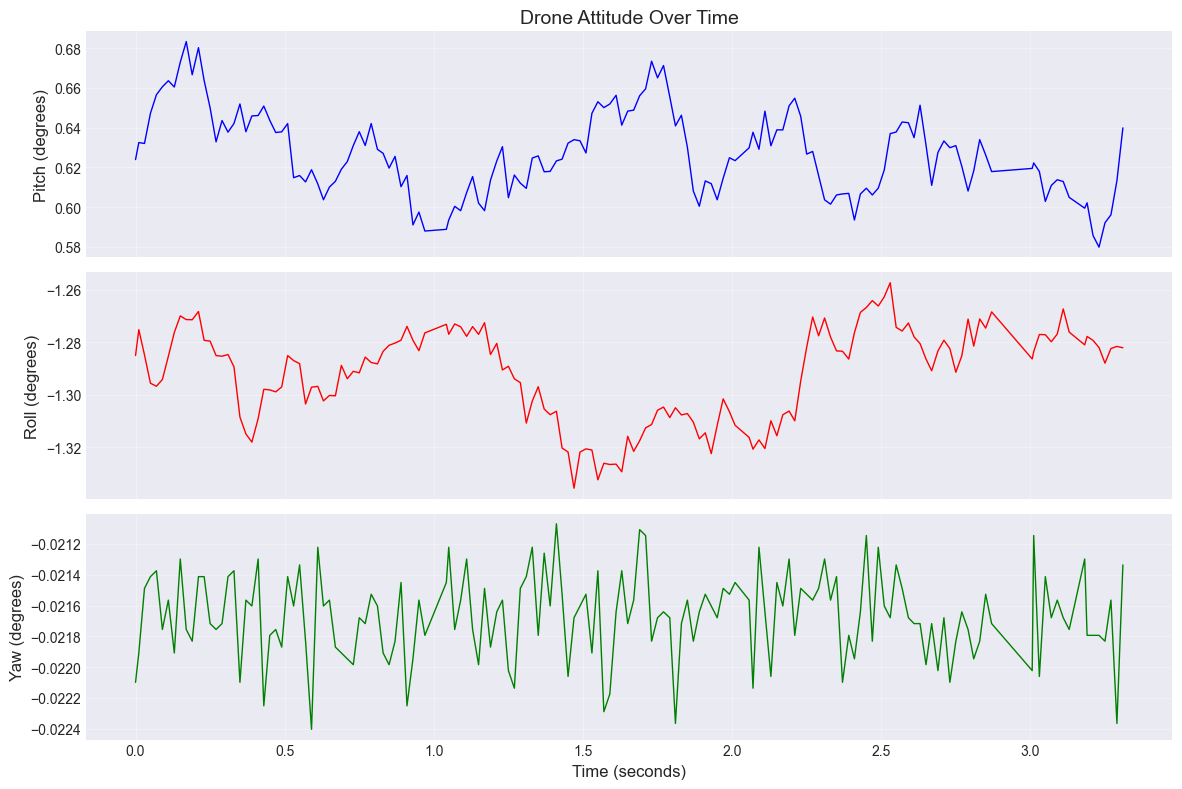

In [98]:
### Visualize Drone Attitude (Pitch, Roll, Yaw) ###

# Plot attitude data
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['time_sec'], df['pitch'], color='blue', linewidth=1)
axes[0].set_ylabel('Pitch (degrees)', fontsize=12)
axes[0].set_title('Drone Attitude Over Time', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['time_sec'], df['roll'], color='red', linewidth=1)
axes[1].set_ylabel('Roll (degrees)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['time_sec'], df['yaw'], color='green', linewidth=1)
axes[2].set_ylabel('Yaw (degrees)', fontsize=12)
axes[2].set_xlabel('Time (seconds)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


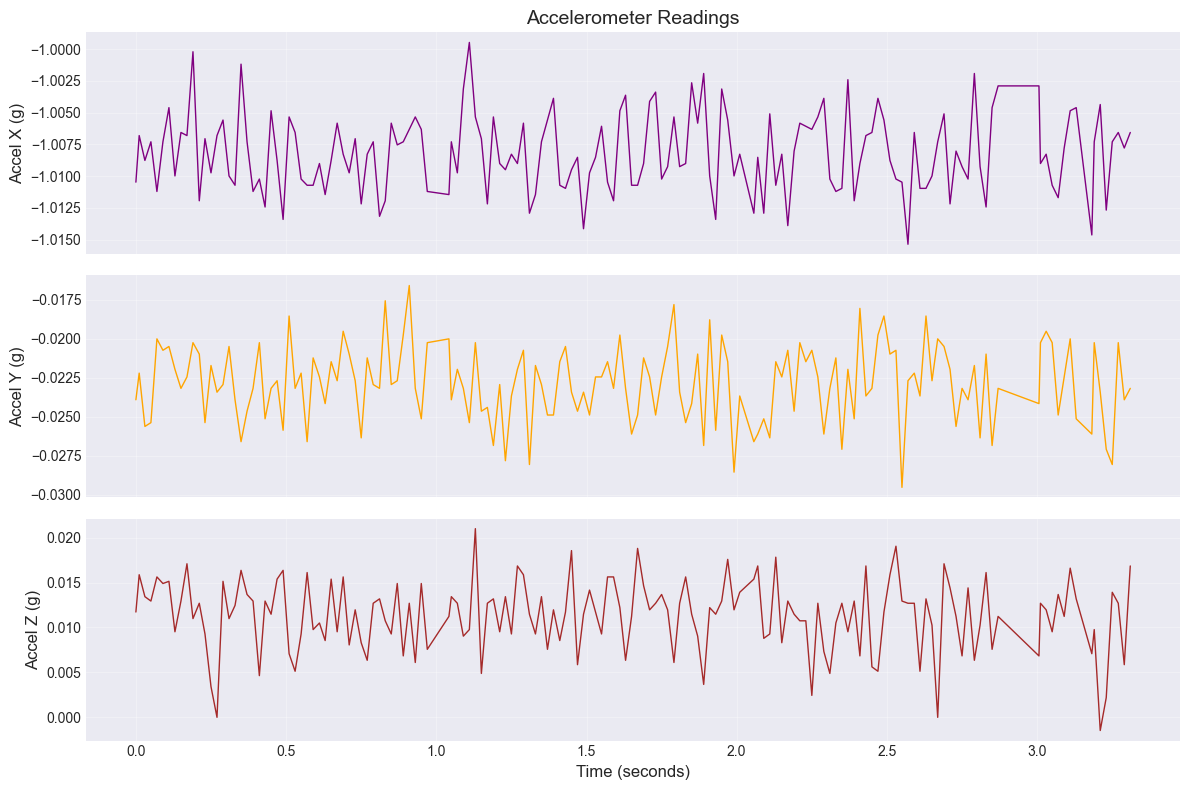

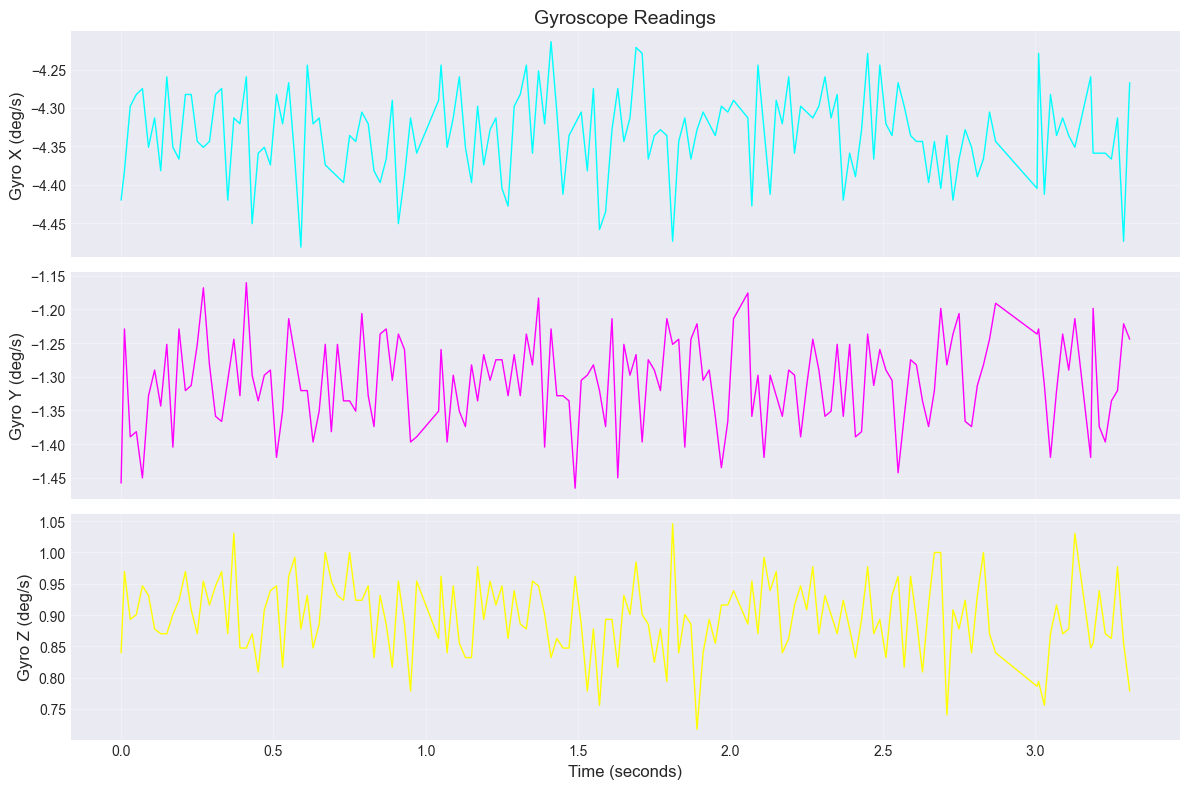

In [99]:
### Accelerometer and Gyroscope Data ###

# Plot accelerometer data
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['time_sec'], df['accel_x'], color='purple', linewidth=1)
axes[0].set_ylabel('Accel X (g)', fontsize=12)
axes[0].set_title('Accelerometer Readings', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['time_sec'], df['accel_y'], color='orange', linewidth=1)
axes[1].set_ylabel('Accel Y (g)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['time_sec'], df['accel_z'], color='brown', linewidth=1)
axes[2].set_ylabel('Accel Z (g)', fontsize=12)
axes[2].set_xlabel('Time (seconds)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot gyroscope data
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['time_sec'], df['gyro_x'], color='cyan', linewidth=1)
axes[0].set_ylabel('Gyro X (deg/s)', fontsize=12)
axes[0].set_title('Gyroscope Readings', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['time_sec'], df['gyro_y'], color='magenta', linewidth=1)
axes[1].set_ylabel('Gyro Y (deg/s)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['time_sec'], df['gyro_z'], color='yellow', linewidth=1)
axes[2].set_ylabel('Gyro Z (deg/s)', fontsize=12)
axes[2].set_xlabel('Time (seconds)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

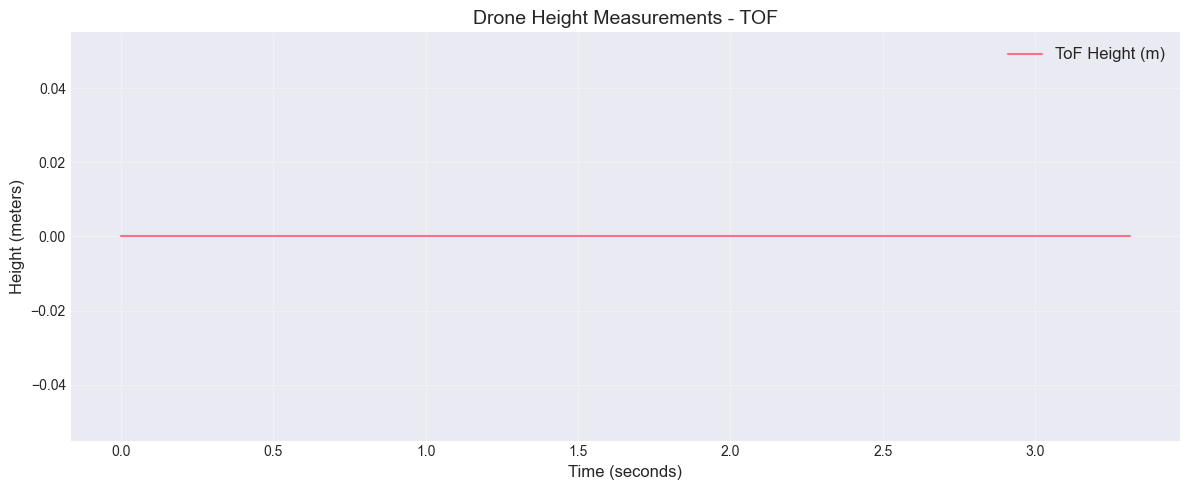

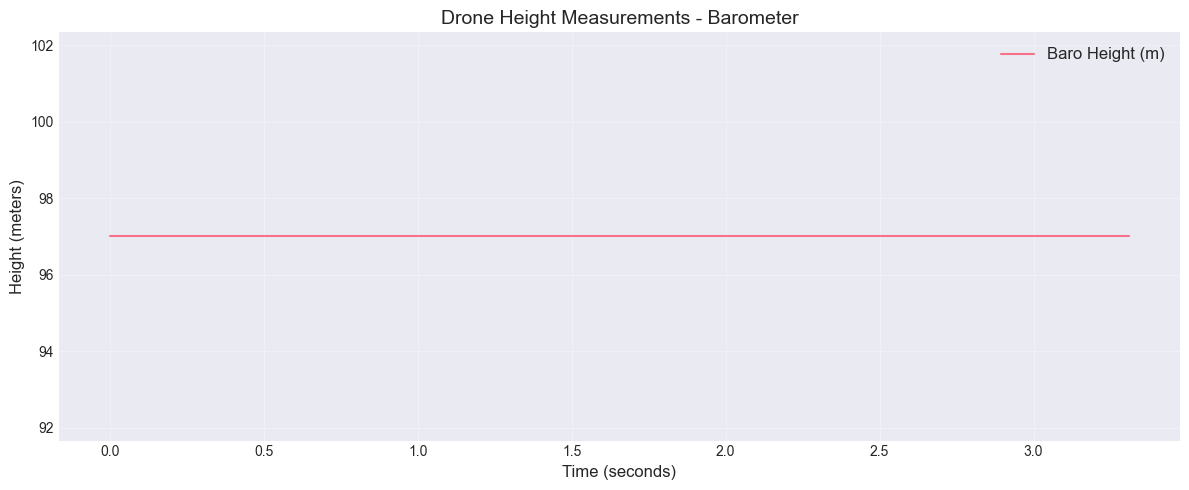

In [100]:
### Height Measurements ###

# Plot height data
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['time_sec'], df['height_tof_m'], label='ToF Height (m)', linewidth=1.5)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Height (meters)', fontsize=12)
ax.set_title('Drone Height Measurements - TOF', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['time_sec'], df['height_baro_m'], label='Baro Height (m)', linewidth=1.5)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Height (meters)', fontsize=12)
ax.set_title('Drone Height Measurements - Barometer', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

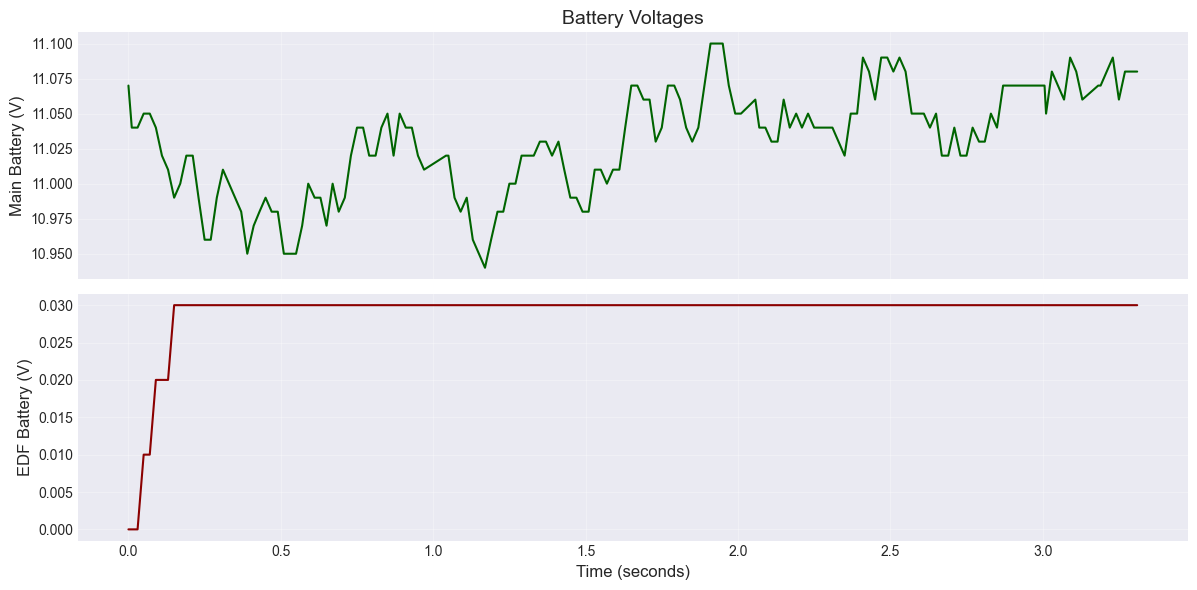

In [101]:
### Battery Voltages ##

# Plot battery voltages
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df['time_sec'], df['battery_main_voltage_v'], color='darkgreen', linewidth=1.5)
axes[0].set_ylabel('Main Battery (V)', fontsize=12)
axes[0].set_title('Battery Voltages', fontsize=14)
axes[0].grid(True, alpha=0.3)
#axes[0].set_ylim([1.0, 1.2])  # Adjust 

axes[1].plot(df['time_sec'], df['battery_edf_voltage_v'], color='darkred', linewidth=1.5)
axes[1].set_ylabel('EDF Battery (V)', fontsize=12)
axes[1].set_xlabel('Time (seconds)', fontsize=12)
axes[1].grid(True, alpha=0.3)
#axes[1].set_ylim([0, 0.005])  # Adjust 

plt.tight_layout()
plt.show()

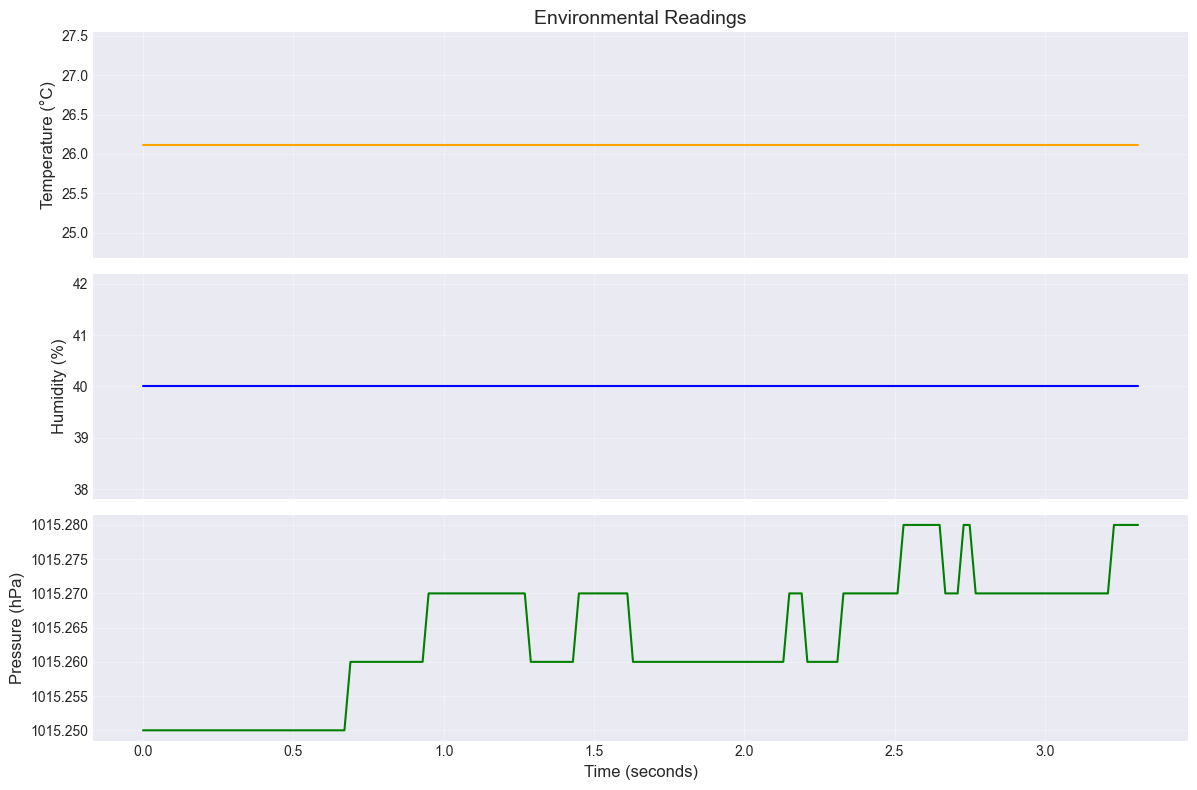

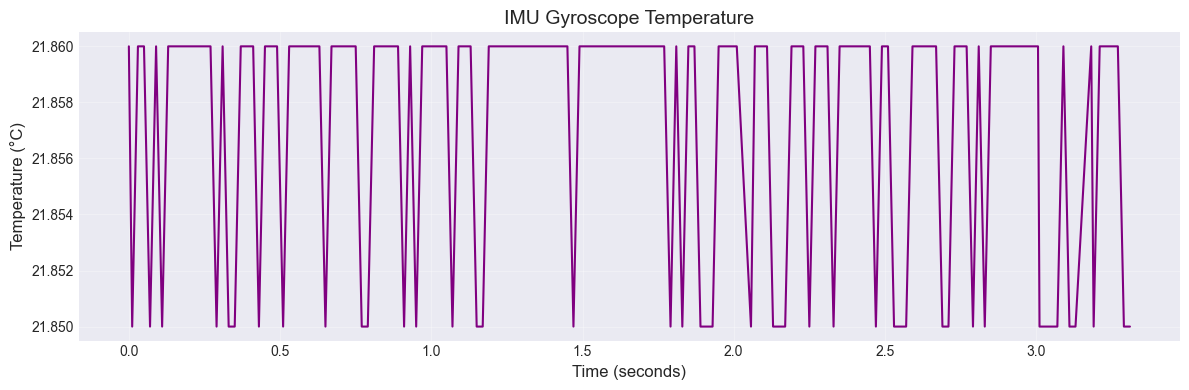

In [102]:
### Environmental Data ###

# Plot environmental data
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['time_sec'], df['temperature_c'], color='orange', linewidth=1.5)
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].set_title('Environmental Readings', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['time_sec'], df['humidity'], color='blue', linewidth=1.5)
axes[1].set_ylabel('Humidity (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['time_sec'], df['pressure_hpa'], color='green', linewidth=1.5)
axes[2].set_ylabel('Pressure (hPa)', fontsize=12)
axes[2].set_xlabel('Time (seconds)', fontsize=12)
axes[2].ticklabel_format(useOffset=False, style='plain')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot gyro temperature
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df['time_sec'], df['gyro_temp_c'], color='purple', linewidth=1.5)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('IMU Gyroscope Temperature', fontsize=14)
ax.ticklabel_format(useOffset=False, style='plain')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

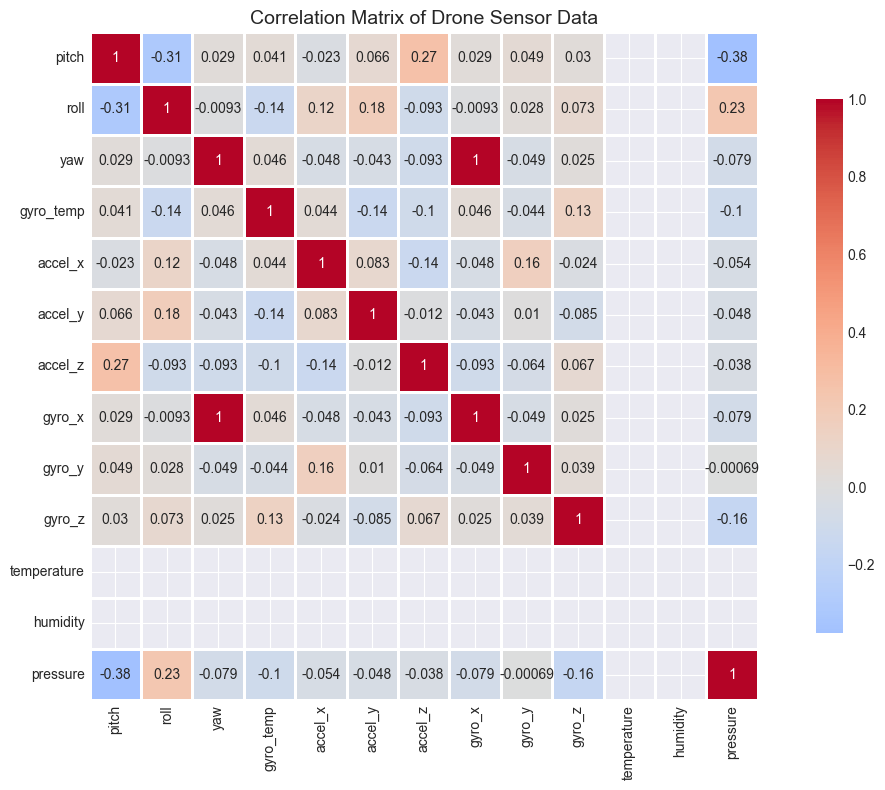

In [103]:
### Correlation Analysis ###

# Select numeric columns for correlation
numeric_cols = ['pitch', 'roll', 'yaw', 'gyro_temp', 'accel_x', 'accel_y', 'accel_z',
                'gyro_x', 'gyro_y', 'gyro_z', 'temperature', 'humidity', 'pressure']

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix of Drone Sensor Data', fontsize=14)
plt.tight_layout()
plt.show()

In [104]:
### Statistical Summary ##

# Create a summary statistics table
summary_stats = df[['pitch', 'roll', 'yaw', 'temperature', 'humidity', 
                    'pressure_hpa', 'height_baro_m']].describe()
print("Summary Statistics:")
summary_stats

# Calculate and display data rate
time_diff = np.diff(df['timestamp'])
avg_time_diff = np.mean(time_diff)
data_rate_hz = 1000 / avg_time_diff 

print(f"Average time between samples: {avg_time_diff:.2f} timestamp units")
print(f"Approximate data rate: {data_rate_hz:.1f} Hz")
print(f"Total recording duration: {df['time_sec'].max():.4f} seconds ({df['time_sec'].max()/360:.2f} minutes)") #60

Summary Statistics:
Average time between samples: 21.08 timestamp units
Approximate data rate: 47.4 Hz
Total recording duration: 3.3100 seconds (0.01 minutes)


In [105]:
### Save Processed Data ###

# Save processed data to a new CSV file
output_file = 'data/drone_log_processed.csv'
df.to_csv(output_file, index=False)
print(f"Processed data saved to {output_file}")

# Display column names in the processed file
print("\nColumns in processed file:")
print(df.columns.tolist())

Processed data saved to data/drone_log_processed.csv

Columns in processed file:
['timestamp', 'pitch', 'roll', 'yaw', 'gyro_temp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'height_tof_mm', 'height_baro_m', 'battery_main_voltage', 'battery_edf_voltage', 'temperature', 'humidity', 'pressure', 'time_sec', 'time_min', 'pressure_hpa', 'height_tof_m', 'temperature_c', 'battery_main_voltage_v', 'battery_edf_voltage_v', 'gyro_temp_c']
